In [1]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent
GRAPH_PATH = (
    PROJECT_ROOT /
    "data" /
    "graph" /
    "financial_graph.pt"
)

In [4]:
graph_data = torch.load(GRAPH_PATH,weights_only=False)
print(graph_data)

Data(x=[19, 16], edge_index=[2, 48])


In [5]:
print(graph_data.x)
print("\nNODE FEATURE SHAPE:\n")
print(graph_data.x.shape)

tensor([[ 3.2700e+00,  1.9038e+02,  1.9458e+02,  5.1062e+01,  5.6000e+00,
          1.5580e+00,  1.9390e+02,  1.2210e+00,  1.9390e+02, -9.9332e-02,
          4.2672e+07, -3.7500e-01,  4.5639e+00,  8.2000e-01,  1.9338e+02,
          1.9318e+02],
        [ 3.2700e+00,  3.6887e+02,  3.7354e+02,  5.7833e+01,  5.6000e+00,
          2.6272e+00,  3.7600e+02,  1.2210e+00,  3.7401e+02, -9.9332e-02,
          1.8731e+07, -3.7500e-01,  4.5639e+00,  8.2000e-01,  3.7485e+02,
          3.7493e+02],
        [ 3.2700e+00,  4.9492e+01,  4.9224e+01,  5.8305e+01,  5.6000e+00,
          6.9705e-01,  4.9813e+01,  1.2210e+00,  4.9041e+01, -9.9332e-02,
          3.8929e+08, -3.7500e-01,  4.5639e+00,  8.2000e-01,  4.9344e+01,
          4.9314e+01],
        [ 3.2700e+00,  1.3978e+02,  1.3998e+02,  5.9313e+01,  5.6000e+00,
          1.8554e+00,  1.4068e+02,  1.2210e+00,  1.4001e+02, -9.9332e-02,
          1.4881e+07, -3.7500e-01,  4.5639e+00,  8.2000e-01,  1.4110e+02,
          1.4184e+02],
        [ 3.2700e+00

In [6]:
print(graph_data.edge_index)
print("\nEDGE SHAPE:\n")
print(graph_data.edge_index.shape)

tensor([[ 0, 10,  1, 10,  2, 10,  3, 10,  4, 10,  5, 10,  8, 13,  9, 13,  5, 12,
          6, 12,  0, 14,  1, 14,  2, 14,  3, 14,  4, 14,  5, 14,  6, 14,  7, 14,
          8, 14,  9, 14, 17, 14, 18, 14, 15, 14, 16, 14],
        [10,  0, 10,  1, 10,  2, 10,  3, 10,  4, 10,  5, 13,  8, 13,  9, 12,  5,
         12,  6, 14,  0, 14,  1, 14,  2, 14,  3, 14,  4, 14,  5, 14,  6, 14,  7,
         14,  8, 14,  9, 14, 17, 14, 18, 14, 15, 14, 16]])

EDGE SHAPE:

torch.Size([2, 48])


In [7]:
G = nx.Graph()

edge_index = graph_data.edge_index.numpy()

for i in range(edge_index.shape[1]):

    src = edge_index[0, i]
    dst = edge_index[1, i]

    G.add_edge(src, dst)

In [8]:
NODES = [
    "AAPL",
    "MSFT",
    "NVDA",
    "GOOG",
    "GOOGL",
    "AMZN",
    "TSLA",
    "BRK-B",
    "JNJ",
    "UNH",
    "XLK",
    "XLF",
    "XLY",
    "XLV",
    "GSPC",
    "N225",
    "FTSE",
    "TNX",
    "FVX"
]

labels = {
    i: node
    for i, node in enumerate(NODES)
}

KeyError: 11

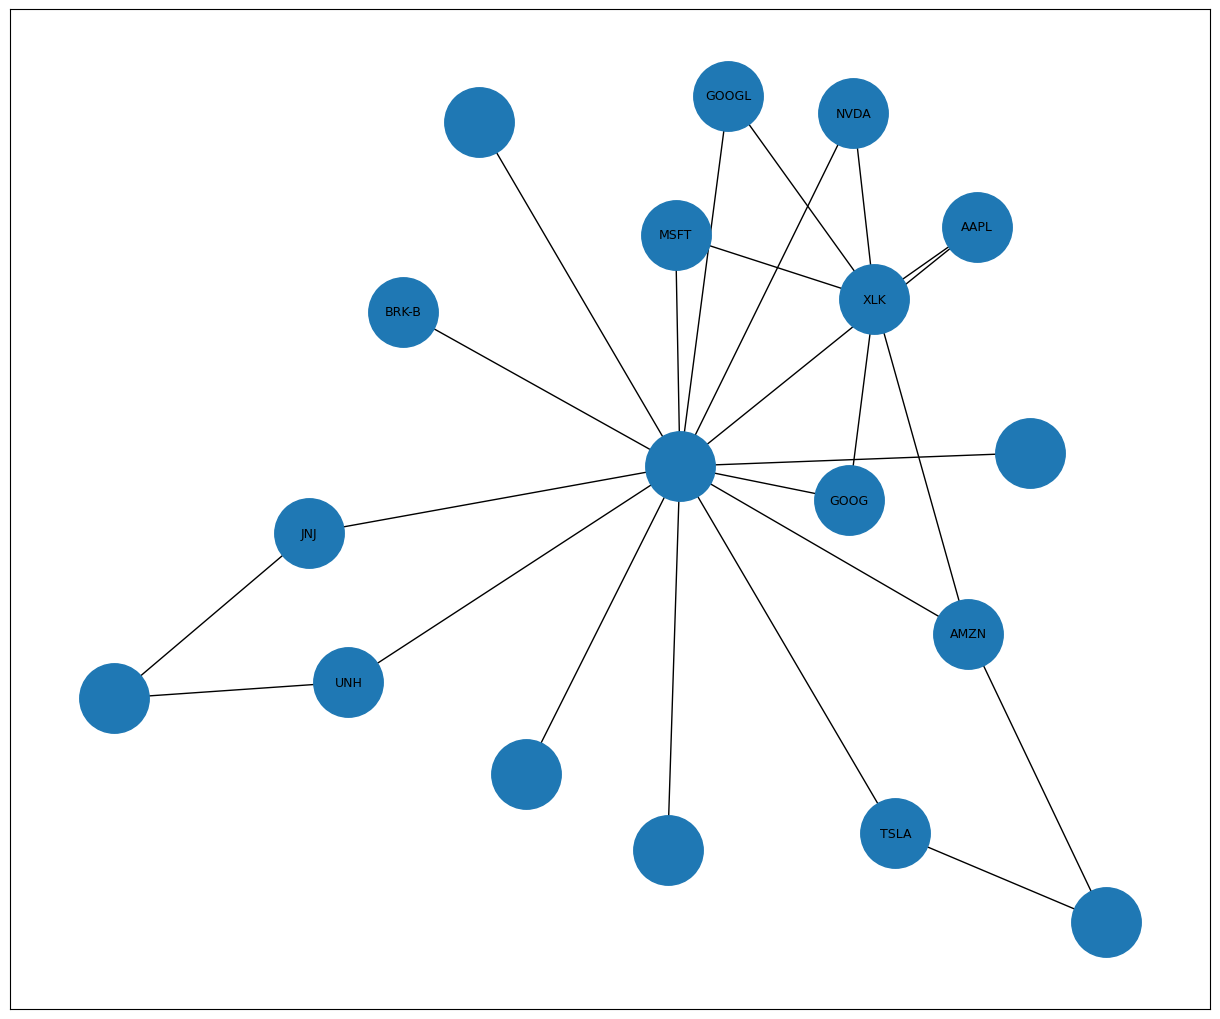

In [9]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=True,
    labels=labels,
    node_size=2500,
    font_size=9
)

plt.title("Financial Graph Topology")

plt.show()